In [32]:
# linear regression practice or excercise 

In [1]:
# importing dataset from uci ml repositary 
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
energy_efficiency = fetch_ucirepo(id=242) 
  
# data (as pandas dataframes) 
X = energy_efficiency.data.features 
y = energy_efficiency.data.targets 

In [2]:
cooling_load = y[["Y2"]]

In [6]:
import pandas as pd
energy = pd.concat([X,cooling_load], axis=1)
energy.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,28.28


In [7]:
import seaborn as sns
import matplotlib.pyplot as  plt 

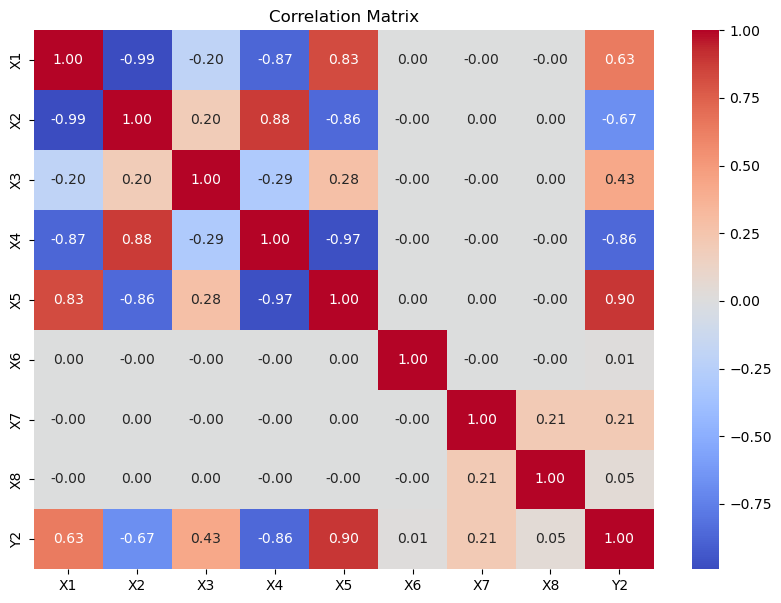

In [8]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    energy.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [10]:
## features and target 
predictive_coloumn = ["X2","X4","X5"]
target_column = "Y2" # cooling load 

In [11]:
from sklearn.preprocessing import StandardScaler


In [14]:
scaler = StandardScaler()

In [15]:
features = energy[predictive_coloumn]

In [16]:
features_scaled = scaler.fit_transform(features)

In [17]:
features_scaled

array([[-1.78587489, -1.47007664,  1.        ],
       [-1.78587489, -1.47007664,  1.        ],
       [-1.78587489, -1.47007664,  1.        ],
       ...,
       [ 1.55394308,  0.97251224, -1.        ],
       [ 1.55394308,  0.97251224, -1.        ],
       [ 1.55394308,  0.97251224, -1.        ]])

In [18]:
target = energy[target_column]
target

0      21.33
1      21.33
2      21.33
3      21.33
4      28.28
       ...  
763    21.40
764    16.88
765    17.11
766    16.61
767    16.03
Name: Y2, Length: 768, dtype: float64

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features_scaled,
    target,
    test_size=0.2,
    random_state=42
)

In [20]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 3)
(154, 3)
(614,)
(154,)


In [21]:
from sklearn.linear_model import LinearRegression

In [23]:
model = LinearRegression()

In [24]:
model.fit(X_train, y_train)

LinearRegression()

In [25]:
y_train_pred = model.predict(X_train)
y_train_pred

array([33.06112812, 17.54371134, 32.04870441, 32.11586968, 16.53128763,
       32.11586968, 32.11586968, 34.07355182, 18.55613504, 17.54371134,
       17.54371134, 17.54371134, 33.06112812, 36.16556448, 36.16556448,
       15.51886393, 18.55613504, 36.16556448, 13.49401653, 30.63081675,
       18.55613504, 34.07355182, 16.53128763, 13.49401653, 36.16556448,
       36.16556448, 14.50644023, 15.51886393, 32.11586968, 13.49401653,
       32.11586968, 17.54371134, 30.63081675, 13.49401653, 14.50644023,
       34.07355182, 32.11586968, 16.53128763, 36.16556448, 13.49401653,
       34.07355182, 34.07355182, 30.63081675, 15.51886393, 30.63081675,
       16.53128763, 14.50644023, 32.11586968, 18.55613504, 32.04870441,
       17.54371134, 33.06112812, 33.06112812, 30.63081675, 32.04870441,
       15.51886393, 33.06112812, 16.53128763, 18.55613504, 30.63081675,
       13.49401653, 15.51886393, 32.11586968, 32.04870441, 33.06112812,
       16.53128763, 33.06112812, 15.51886393, 30.63081675, 34.07

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [27]:
import numpy as np
train_mse = mean_squared_error(y_true=y_train, y_pred=y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_true=y_train, y_pred=y_train_pred)
train_r2 = r2_score(y_true=y_train, y_pred=y_train_pred)

In [28]:
print("train preformance ")
print("Train MSE :", train_mse)
print("Train RMSE:", train_rmse)
print("Train MAE :", train_mae)
print("Train R²  :", train_r2)

train preformance 
Train MSE : 14.848155044784448
Train RMSE: 3.853330383549333
Train MAE : 2.916381191307761
Train R²  : 0.8343931009125967


In [29]:
#test data prediction 
y_test_pred = model.predict(X_test)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

In [30]:
print("Test Performance")

print("Test MSE  :", test_mse)
print("Test RMSE :", test_rmse)
print("Test MAE  :", test_mae)
print("Test R²   :", test_r2)

Test Performance
Test MSE  : 13.62059730650891
Test RMSE : 3.6906093408147265
Test MAE  : 2.781771026499002
Test R²   : 0.8530001781994246


## Conclusion

The Linear Regression model achieved an R² score of approximately 0.85
on the Cooling Load test dataset.

The training and testing performances are similar, indicating that the
model generalizes reasonably well to unseen data and shows no obvious
sign of overfitting.

The test MAE is approximately 2.78, meaning that the predicted Cooling
Load differs from the actual value by about 2.78 units on average.

Overall, the selected features X2, X4, and X5 provide a useful baseline
for predicting Cooling Load.